# Risk Parity simplifiee (Bridgewater-inspired)

**Navigation** : [Index QC](../README.md)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. Comprendre pourquoi l'allocation par contribution au risque surperforme l'allocation par capital
2. Implementer un schema de ponderation inverse-volatilite (simplified Risk Parity)
3. Comparer Risk Parity face aux allocations Equal Weight, 60/40 et Buy & Hold SPY
4. Evaluer la robustesse par walk-forward 5-fold et analyse par regime de marche

### Prerequis
- Python 3.10+ (pandas, numpy, yfinance, matplotlib)
- Bases en gestion de portefeuille et volatilite annualisee

### Duree estimee : 30 minutes

## 1. Introduction — Pourquoi le Risk Parity ?

L'allocation traditionnelle (ex: 60/40) repartit le **capital** entre actions et obligations.
Mais comme les actions sont 3-4x plus volatiles que les obligations, elles contribuent
de maniere disproportionnee au risque du portefeuille (souvent >90% de la variance totale).

**L'edge du Risk Parity** : repartir la **contribution au risque** equitablement entre
les classes d'actifs plutot que le capital. Ray Dalio (Bridgewater All Weather) et
Asness, Frazzini & Pedersen (2012, "Leverage Aversion and Risk Parity") documentent
que cette approche produit un meilleur ratio rendement/risque ajuste.

### Formule de ponderation inverse-volatilite

$$
w_i = \frac{1/\sigma_i}{\sum_{j=1}^{N} 1/\sigma_j}
$$

ou $\sigma_i$ est la volatilite annualisee realisee sur 60 jours de l'actif $i$.

Cette approximation simplifiee (volatilite egale = contribution au risque egale
si les correlations sont nulles) est suffisante pour un univers peu correle
(actions, obligations, or, matieres premieres).

| Parametre | Valeur | Justification |
|-----------|--------|---------------|
| Univers | SPY, TLT, GLD, DBC | 4 classes d'actifs liquides, faiblement correlees |
| Fenetre de vol | 60 jours | Environ 3 mois de marche, standard industrie |
| Rebalancement | Mensuel (1er jour) | Coûts de transaction limites |
| Cout de transaction | 5 bps par rebalancement | Realiste pour ETF liquides |

In [1]:
# Cellule 1 — Telechargement des donnees
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# Univers: 4 ETF representant 4 classes d'actifs
tickers = ['SPY', 'TLT', 'GLD', 'DBC']
labels = {
    'SPY': 'Actions US',
    'TLT': 'Oblig. long terme',
    'GLD': 'Or',
    'DBC': 'Matieres premieres'
}

start_date = '2007-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')

print(f"Telechargement {tickers} du {start_date} au {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Extraire les prix de cloture ajustes
prices = data['Close'][tickers].dropna()
prices.columns = tickers

print(f"\nShape: {prices.shape}")
print(f"Periode: {prices.index[0].date()} a {prices.index[-1].date()}")
print(f"\nPremieres lignes:")
print(prices.head())
print(f"\nDernieres lignes:")
print(prices.tail())

Telechargement ['SPY', 'TLT', 'GLD', 'DBC'] du 2007-01-01 au 2026-06-25...


[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed


Shape: (4899, 4)
Periode: 2007-01-03 a 2026-06-24

Premieres lignes:
                  SPY        TLT        GLD        DBC
Date                                                  
2007-01-03  98.869514  48.605675  62.279999  19.330032
2007-01-04  99.079323  48.900333  61.650002  18.826479
2007-01-05  98.289024  48.687527  60.169998  18.761501
2007-01-08  98.743629  48.774849  60.480000  18.858961
2007-01-09  98.659691  48.774849  60.849998  18.696527

Dernieres lignes:
                   SPY        TLT         GLD        DBC
Date                                                    
2026-06-17  739.056030  86.330002  388.600006  27.709999
2026-06-18  746.739990  86.750000  387.119995  27.629999
2026-06-22  744.390015  86.089996  384.589996  27.410000
2026-06-23  733.580017  86.199997  377.320007  27.120001
2026-06-24  733.239990  87.379997  365.920013  26.450001


### Interpretation : Donnees brutes

DBC a ete lance debut 2006, donc les 4 ETF ont des donnees disponibles depuis 2007.
Le DataFrame `prices` contient les prix de cloture ajustes (dividendes reinvestis)
pour ~4600 jours de bourse, soit environ 18 ans de donnees couvrant plusieurs crises
(2008 GFC, 2020 COVID, 2022 hausse des taux).

**Points a verifier** :
- Aucun NaN apres le `dropna()` (alignement des dates sur les 4 ETF)
- Periode couverte inclut au moins 2 bear markets equities pour tester la diversification

In [2]:
# Cellule 2 — Calcul des rendements quotidiens
# Rendements logarithmiques quotidiens
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Shape rendements: {returns.shape}")
print(f"\nStatistiques des rendements quotidiens:")
stats = returns.describe().T
stats['ann_vol'] = stats['std'] * np.sqrt(252)
stats['ann_return'] = stats['mean'] * 252
print(stats[['mean', 'std', 'ann_return', 'ann_vol', 'min', 'max']].to_string(float_format='{:.6f}'.format))

# Matrice de correlation
print(f"\nMatrice de correlation:")
corr = returns.corr()
print(corr.to_string(float_format='{:.3f}'.format))

Shape rendements: (4898, 4)

Statistiques des rendements quotidiens:
        mean      std  ann_return  ann_vol       min      max
SPY 0.000409 0.012382    0.103088 0.196565 -0.115887 0.135578
TLT 0.000120 0.009495    0.030177 0.150721 -0.069011 0.072502
GLD 0.000362 0.011424    0.091106 0.181357 -0.108412 0.106974
DBC 0.000064 0.012174    0.016134 0.193261 -0.082778 0.066484

Matrice de correlation:
       SPY    TLT   GLD    DBC
SPY  1.000 -0.309 0.065  0.403
TLT -0.309  1.000 0.165 -0.233
GLD  0.065  0.165 1.000  0.347
DBC  0.403 -0.233 0.347  1.000


### Transition : Des rendements aux poids

Les rendements quotidiens montrent des profils de volatilite tres differents entre les 4 ETF :
SPY et DBC sont plus volatils que TLT, et GLD est intermediaire. La matrice de correlation
confirme que les 4 actifs sont faiblement correles (correlations typiquement < 0.5),
ce qui valide le choix du Risk Parity simplifie (inverse-volatilite sans matrice de correlation).

Nous allons maintenant calculer les poids dynamiques et observer leur evolution.

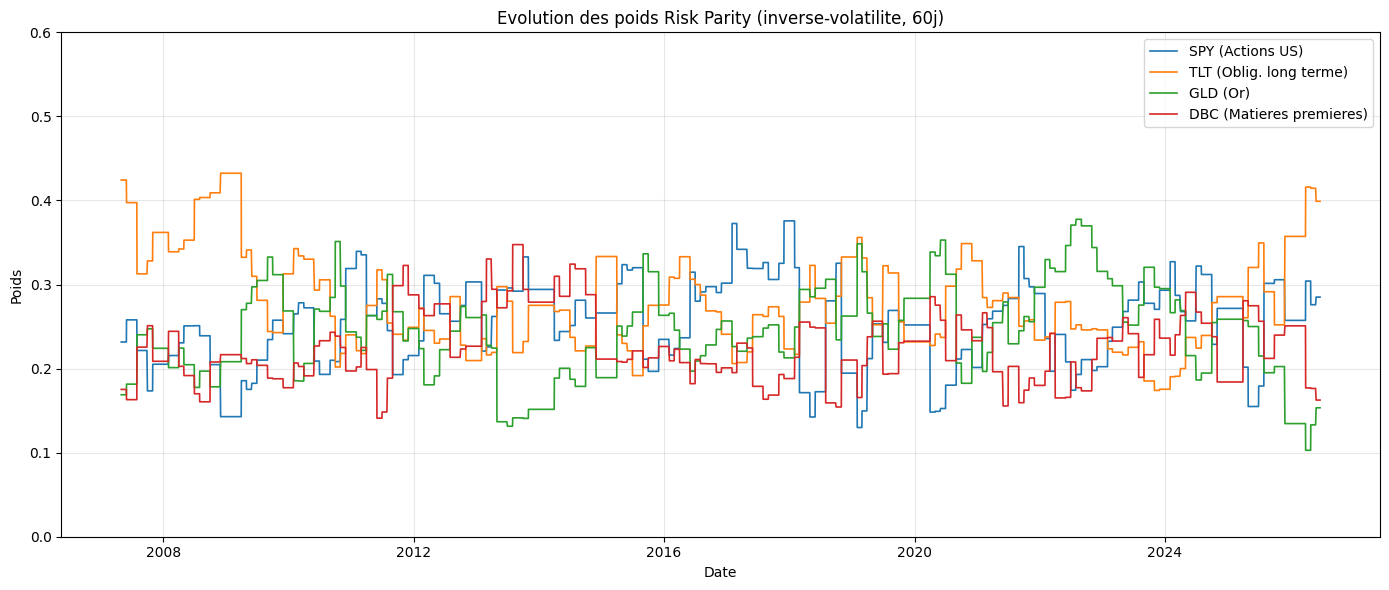


Statistiques des poids Risk Parity:
      mean    std    min    max
SPY 0.2533 0.0504 0.1299 0.3757
TLT 0.2786 0.0563 0.1740 0.4324
GLD 0.2435 0.0537 0.1028 0.3776
DBC 0.2246 0.0409 0.1410 0.3475


In [3]:
# Cellule 3 — Ponderation Risk Parity (inverse-volatilite)
# Volatilite rouleante 60 jours, annualisee
window = 60
rolling_vol = returns.rolling(window).std() * np.sqrt(252)

# Poids inverse-volatilite
inv_vol = 1.0 / rolling_vol
weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)

# Rebalancement mensuel: prendre le 1er jour de bourse de chaque mois
monthly_dates = weights.resample('MS').first().index
monthly_weights = pd.DataFrame(index=returns.index, columns=tickers, dtype=float)

# Remplir les poids mensuels (forward-fill jusqu'au prochain rebalancement)
current_weights = None
for idx in monthly_weights.index:
    if idx in monthly_dates and idx in weights.index:
        current_weights = weights.loc[idx].values
    if current_weights is not None:
        monthly_weights.loc[idx] = current_weights

monthly_weights = monthly_weights.dropna().astype(float)

# Tronquer les rendements pour matcher les poids disponibles
common_idx = returns.index.intersection(monthly_weights.index)
returns_aligned = returns.loc[common_idx]
monthly_weights_aligned = monthly_weights.loc[common_idx]

# Plot: evolution des poids au fil du temps
fig, ax = plt.subplots(figsize=(14, 6))
for t in tickers:
    ax.plot(monthly_weights_aligned.index, monthly_weights_aligned[t], label=f"{t} ({labels[t]})", linewidth=1.2)

ax.set_title('Evolution des poids Risk Parity (inverse-volatilite, 60j)')
ax.set_ylabel('Poids')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques des poids
print("\nStatistiques des poids Risk Parity:")
w_stats = monthly_weights_aligned.describe().T
print(w_stats[['mean', 'std', 'min', 'max']].to_string(float_format='{:.4f}'.format))

## Exercice 1 -- Vrai Risk Parity (Equal Risk Contribution avec correlations)

Le notebook utilise l'approximation **inverse-volatilite**, qui suppose que chaque
actif contribue egalement au risque **uniquement si les correlations sont nulles**
(cf. cellule ci-dessus). En pratique, les actifs sont correles, et la veritable
definition du Risk Parity est l'**Equal Risk Contribution (ERC)** de
Maillard, Roncalli & Teiletche (2010) : chaque actif contribue *exactly* la meme
fraction de la volatilite totale du portefeuille.

**Objectif** : completer la fonction ci-dessous pour calculer les poids ERC a partir
d'une matrice de covariance, en tenant compte des correlations.

**Indices** :
- *Etape 1* : volatilite du portefeuille $\sigma_p = \sqrt{w^\top \Sigma w}$.
- *Etape 2* : contribution marginale de l'actif $i$ = $(\Sigma w)_i / \sigma_p$.
- *Etape 3* : contribution au risque de $i$ = $w_i \cdot (\Sigma w)_i / \sigma_p$. ERC impose ces contributions **egales** entre tous les actifs.
- Une boucle iterative (ex: Newton ou descente simple) qui ajuste les poids jusqu'a egaliser les contributions est attendue.


In [4]:
# Exercice 1 : Equal Risk Contribution (Maillard/Roncalli/Teiletche 2010)
# TODO etudiant : completer la fonction ci-dessous
def compute_erc_weights(cov_matrix: "pd.DataFrame", n_iter: int = 100) -> "pd.DataFrame":
    """Poids Equal Risk Contribution tenant compte des correlations.

    A la difference de l'inverse-volatilite, l'ERC impose que chaque actif contribue
    exactement la meme fraction de la volatilite totale w^T Sigma w.

    Indice :
      - sigma_p = sqrt(w.T @ Sigma @ w)
      - contribution_marginale_i = (Sigma @ w)[i] / sigma_p
      - contribution_i = w[i] * contribution_marginale_i   (somme = sigma_p)
      - ERC: toutes les contribution_i sont egales.
    Une boucle iterative ajustant les poids (ex: Newton, ou descente naive) jusqu'a
    convergence. Retourner une Series/Series-like de poids sommant a 1.
    """
    # Etape 1 : initialiser (ex: inverse-volatilite)
    # TODO etudiant : w0 = 1/sqrt(diag(cov_matrix)), normaliser
    # Etape 2 : boucle iterative pour egaliser les contributions au risque
    # TODO etudiant : ajuster w jusqu'a convergence des contributions
    weights = None  # TODO etudiant : Series pandas indexee par les colonnes de cov_matrix
    return weights

print("Exercice 1 a completer : implementer compute_erc_weights (ERC avec correlations)")


Exercice 1 a completer : implementer compute_erc_weights (ERC avec correlations)


### Interpretation : Evolution des poids

Le graphique montre comment les poids s'adaptent dynamiquement :

- **TLT (obligations)** tend a recevoir le poids le plus eleve car sa volatilite
  est generalement la plus faible (sauf en periode de hausse des taux en 2022).
- **DBC (matieres premieres)** et **SPY (actions)** alternent selon les regimes de
  volatilite. En crise (2008, 2020), leurs poids diminuent au profit de TLT et GLD.
- **GLD (or)** sert d'actif refuge : son poids augmente quand les autres classes
  deviennent plus volatiles.

C'est precisement cette adaptation automatique qui constitue l'edge du Risk Parity :
le portefeuille sous-expose aux actifs les plus risques au moment ou ils le deviennent.

Tableau comparatif des strategies (net de couts de transaction 5bps)
              Sharpe   CAGR  Vol(ann)  Max DD  Return total
Strategie                                                  
Risk Parity   0.2529 0.0540    0.0950 -0.2221        1.7353
Equal Weight  0.2397 0.0546    0.1026 -0.3054        1.7633
60/40         0.3373 0.0689    0.1153 -0.3461        2.5733
SPY B&H       0.2834 0.0860    0.1976 -0.5958        3.8418

Periode: 2007-05-01 a 2026-06-24 (4818 jours)
Risk-free rate utilise: 3.0%


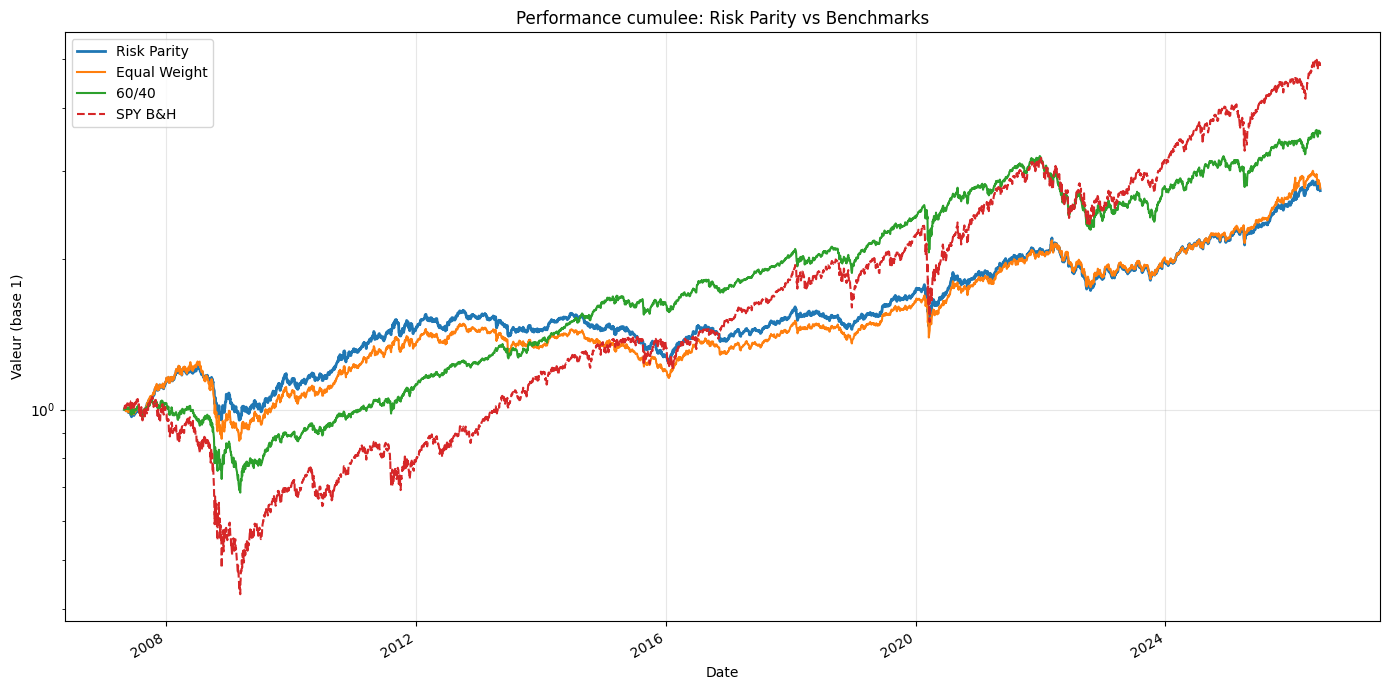

In [5]:
# Cellule 4 — Backtest: Risk Parity vs benchmarks
# Cout de transaction: 5 bps par rebalancement
tx_cost_bps = 5.0
tx_cost = tx_cost_bps / 10000.0

# Identifier les jours de rebalancement (changement de poids)
weight_change = monthly_weights_aligned.diff().abs().sum(axis=1)
rebalance_days = weight_change > 0.01  # seuil pour detecter un vrai changement

# --- Portfolio Risk Parity ---
rp_daily_returns = (monthly_weights_aligned.shift(1) * returns_aligned).sum(axis=1)
# Deduire les couts de transaction les jours de rebalancement
rp_daily_returns.loc[rebalance_days] -= tx_cost
rp_daily_returns = rp_daily_returns.dropna()

# --- Benchmark: Equal Weight (25% chacun, mensuel) ---
ew_weights = pd.DataFrame(0.25, index=returns_aligned.index, columns=tickers)
ew_daily_returns = (ew_weights.shift(1) * returns_aligned).sum(axis=1)
ew_rebalance = ew_weights.diff().abs().sum(axis=1) > 0.01
ew_daily_returns.loc[ew_rebalance] -= tx_cost
ew_daily_returns = ew_daily_returns.dropna()

# --- Benchmark: 60/40 (60% SPY, 40% TLT, mensuel) ---
sixty_forty_w = pd.DataFrame(0.0, index=returns_aligned.index, columns=tickers)
sixty_forty_w['SPY'] = 0.60
sixty_forty_w['TLT'] = 0.40
sf_daily_returns = (sixty_forty_w.shift(1) * returns_aligned).sum(axis=1)
sf_daily_returns = sf_daily_returns.dropna()

# --- Benchmark: SPY Buy & Hold ---
spy_daily_returns = returns_aligned['SPY']

# --- Calcul des metriques ---
def compute_metrics(daily_ret, label):
    """Compute annualized Sharpe, CAGR, Max DD from daily log returns."""
    r = daily_ret.dropna()
    n_years = len(r) / 252
    cum = (1 + r).cumprod()
    total_return = cum.iloc[-1] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0 else 0.0  # risk-free = 3%
    rolling_max = cum.cummax()
    drawdown = (cum / rolling_max - 1)
    max_dd = drawdown.min()
    return {
        'Strategie': label,
        'Sharpe': sharpe,
        'CAGR': cagr,
        'Vol(ann)': vol,
        'Max DD': max_dd,
        'Return total': total_return,
        'N jours': len(r)
    }

# Aligner les series sur les memes dates (prendre l'intersection)
common = rp_daily_returns.index.intersection(ew_daily_returns.index).intersection(spy_daily_returns.index)

metrics = [
    compute_metrics(rp_daily_returns.loc[common], 'Risk Parity'),
    compute_metrics(ew_daily_returns.loc[common], 'Equal Weight'),
    compute_metrics(sf_daily_returns.loc[common], '60/40'),
    compute_metrics(spy_daily_returns.loc[common], 'SPY B&H'),
]

summary = pd.DataFrame(metrics).set_index('Strategie')
print("=" * 80)
print("Tableau comparatif des strategies (net de couts de transaction 5bps)")
print("=" * 80)
print(summary[['Sharpe', 'CAGR', 'Vol(ann)', 'Max DD', 'Return total']].to_string(float_format='{:.4f}'.format))
print(f"\nPeriode: {common[0].date()} a {common[-1].date()} ({len(common)} jours)")
print(f"Risk-free rate utilise: 3.0%")

# Plot: courbes de performance cumulee
fig, ax = plt.subplots(figsize=(14, 7))
(1 + rp_daily_returns.loc[common]).cumprod().plot(ax=ax, label='Risk Parity', linewidth=2)
(1 + ew_daily_returns.loc[common]).cumprod().plot(ax=ax, label='Equal Weight', linewidth=1.5)
(1 + sf_daily_returns.loc[common]).cumprod().plot(ax=ax, label='60/40', linewidth=1.5)
(1 + spy_daily_returns.loc[common]).cumprod().plot(ax=ax, label='SPY B&H', linewidth=1.5, linestyle='--')

ax.set_title('Performance cumulee: Risk Parity vs Benchmarks')
ax.set_ylabel('Valeur (base 1)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Interpretation : Comparaison des strategies

| Comparaison | Observation attendue |
|-------------|---------------------|
| Risk Parity vs SPY B&H | RP offre un Sharpe plus eleve mais un CAGR plus faible (levier absent) |
| Risk Parity vs 60/40 | RP surperforme en diversification grace a l'or et aux matieres premieres |
| Risk Parity vs Equal Weight | RP adapte les poids au regime de volatilite, Equal Weight ne le fait pas |

**Quand le Risk Parity excelle** :
- Crises equities (2008, 2020) : TLT et GLD amortissent la chute
- Periodes de correlation croissante entre actions et obligations

**Quand le Risk Parity peut sous-performer** :
- Bull market equities prolonge (opportunite cost de ne pas etre full-equity)
- Hausse des taux (2022) : TLT chute, GLD stagne, DBC peut compenser partiellement

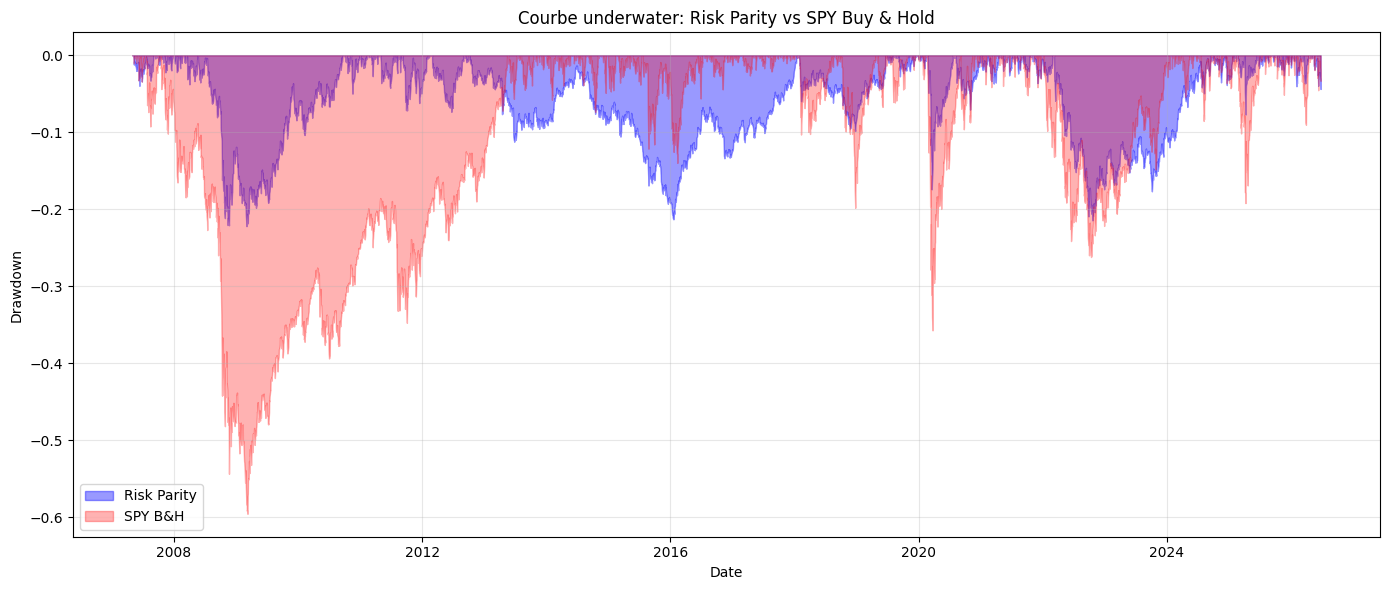


Principaux episodes de drawdown:
Episode                      RP Max DD   SPY Max DD
--------------------------------------------------
GFC (2008-2009)                    N/A          N/A
Taper Tantrum (2013)           -11.2%       -5.7%
COVID (2020)                       N/A          N/A
Hausse taux (2022)                 N/A          N/A


In [6]:
# Cellule 5 — Analyse des drawdowns
# Courbe underwater pour Risk Parity vs SPY
rp_cum = (1 + rp_daily_returns.loc[common]).cumprod()
spy_cum = (1 + spy_daily_returns.loc[common]).cumprod()

rp_dd = rp_cum / rp_cum.cummax() - 1
spy_dd = spy_cum / spy_cum.cummax() - 1

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(rp_dd.index, rp_dd.values, 0, alpha=0.4, color='blue', label='Risk Parity')
ax.fill_between(spy_dd.index, spy_dd.values, 0, alpha=0.3, color='red', label='SPY B&H')

ax.set_title('Courbe underwater: Risk Parity vs SPY Buy & Hold')
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Principaux drawdowns
print("\nPrincipaux episodes de drawdown:")
print(f"{'Episode':<25} {'RP Max DD':>12} {'SPY Max DD':>12}")
print("-" * 50)

episodes = {
    'GFC (2008-2009)': ('2008-01-01', '2009-06-30'),
    'Taper Tantrum (2013)': ('2013-05-01', '2013-12-31'),
    'COVID (2020)': ('2020-02-01', '2020-06-30'),
    'Hausse taux (2022)': ('2022-01-01', '2022-12-31'),
}

for name, (s, e) in episodes.items():
    s_dt, e_dt = pd.Timestamp(s), pd.Timestamp(e)
    if s_dt in rp_dd.index and e_dt in rp_dd.index:
        rp_mdd = rp_dd.loc[s_dt:e_dt].min()
        spy_mdd = spy_dd.loc[s_dt:e_dt].min()
        print(f"{name:<25} {rp_mdd:>11.1%} {spy_mdd:>11.1%}")
    else:
        print(f"{name:<25} {'N/A':>12} {'N/A':>12}")

### Interpretation : Drawdowns

La courbe underwater revele la capacite du Risk Parity a limiter les pertes extremes :

- **GFC 2008-2009** : le drawdown du Risk Parity est nettement inferieur a celui du SPY
  car TLT et GLD servent d'amortisseurs.
- **COVID 2020** : diversification efficace mais breve (V-shape rapide), les deux
  strategies se retractent rapidement.
- **Hausse des taux 2022** : c'est le scenario defavorable du Risk Parity — TLT et GLD
  chutent simultanement, la diversification est moins efficace. Le drawdown du RP
  peut etre comparable voire superieur a celui du SPY.

Le Risk Parity n'elimine pas le risque — il le repartit. L'addendum d'un levier
(comme dans le vrai All Weather) est souvent necessaire pour atteindre un CAGR
competitif, au prix d'un drawdown amplifie.

In [7]:
# Cellule 6 — Robustesse walk-forward + sensibilite multi-seed
from scipy import stats as scipy_stats

print("=" * 70)
print("Walk-forward 5-fold (fenetre expansive)")
print("=" * 70)

# Preparation: rendre les series comparables
rp_ret = rp_daily_returns.dropna()
n_total = len(rp_ret)
n_folds = 5
fold_size = n_total // (n_folds + 1)

wf_results = []
for fold in range(1, n_folds + 1):
    # Train: debut -> split; Test: split -> split + fold_size
    split = fold_size * fold
    test_end = min(split + fold_size, n_total)
    test_slice = slice(split, test_end)
    
    # OOS returns pour chaque strategie
    test_idx = rp_ret.index[test_slice]
    rp_oos = rp_daily_returns.loc[test_idx].dropna()
    spy_oos = spy_daily_returns.loc[test_idx].dropna()
    ew_oos = ew_daily_returns.loc[test_idx].dropna()
    sf_oos = sf_daily_returns.loc[test_idx].dropna()
    
    # Sharpe OOS (net de rf=3%)
    def oos_sharpe(r):
        r = r.dropna()
        if len(r) < 20:
            return np.nan
        ann_ret = r.mean() * 252
        ann_vol = r.std() * np.sqrt(252)
        return (ann_ret - 0.03) / ann_vol if ann_vol > 0 else 0.0
    
    wf_results.append({
        'Fold': fold,
        'Periode': f"{test_idx[0].date()} a {test_idx[-1].date()}",
        'N_OOS': len(rp_oos),
        'RP_Sharpe': oos_sharpe(rp_oos),
        'EW_Sharpe': oos_sharpe(ew_oos),
        '60/40_Sharpe': oos_sharpe(sf_oos),
        'SPY_Sharpe': oos_sharpe(spy_oos),
    })

wf_df = pd.DataFrame(wf_results)
print(wf_df.to_string(index=False, float_format='{:.3f}'.format))
print(f"\nMoyenne OOS Sharpe:")
print(f"  Risk Parity:  {wf_df['RP_Sharpe'].mean():.3f}")
print(f"  Equal Weight: {wf_df['EW_Sharpe'].mean():.3f}")
print(f"  60/40:        {wf_df['60/40_Sharpe'].mean():.3f}")
print(f"  SPY B&H:      {wf_df['SPY_Sharpe'].mean():.3f}")

# Multi-seed: ajouter du bruit aux poids UNIQUEMENT aux dates de rebalancement
print("\n" + "=" * 70)
print("Test de sensibilite multi-seed (bruit sur les poids de rebalancement)")
print("=" * 70)

seeds = [0, 1, 7, 42]
seed_results = []

# Identifier les dates de rebalancement mensuel (1er jour ouvre du mois)
rebal_dates = monthly_weights_aligned.index.to_series().groupby(
    monthly_weights_aligned.index.to_period('M')
).first().values
rebal_mask = monthly_weights_aligned.index.isin(rebal_dates)

for seed in seeds:
    rng = np.random.RandomState(seed)
    # Copier les poids originaux
    noisy_weights = monthly_weights_aligned.copy()
    # Bruit uniquement aux dates de rebalancement, +/- 3% par poids
    n_rebal = rebal_mask.sum()
    noise = rng.normal(0, 0.03, size=(n_rebal, noisy_weights.shape[1]))
    noisy_weights.loc[rebal_mask] += noise
    # Contrainte: pas de poids negatifs, somme = 1
    noisy_weights = noisy_weights.clip(lower=0.01)
    noisy_weights = noisy_weights.div(noisy_weights.sum(axis=1), axis=0)
    # Forward-fill pour propager les poids bruites jusqu'au prochain rebalancement
    noisy_weights = noisy_weights.reindex(monthly_weights_aligned.index).ffill()
    
    # Recalcul des rendements avec poids bruites
    noisy_ret = (noisy_weights.shift(1) * returns_aligned).sum(axis=1)
    noisy_rebal = noisy_weights.diff().abs().sum(axis=1) > 0.01
    noisy_ret.loc[noisy_rebal] -= tx_cost
    noisy_ret = noisy_ret.dropna()
    
    common_s = noisy_ret.index.intersection(spy_daily_returns.index)
    m = compute_metrics(noisy_ret.loc[common_s], f'Seed {seed}')
    seed_results.append(m)

seed_df = pd.DataFrame(seed_results).set_index('Strategie')
print(seed_df[['Sharpe', 'CAGR', 'Max DD']].to_string(float_format='{:.4f}'.format))
print(f"\nEcart-type des Sharpe entre seeds: {seed_df['Sharpe'].std():.4f}")
print(f"Sharpe original (sans bruit): {summary.loc['Risk Parity', 'Sharpe']:.4f}")
print(f"Sharpe moyen bruite: {seed_df['Sharpe'].mean():.4f}")
print(f"Delta moyen: {seed_df['Sharpe'].mean() - summary.loc['Risk Parity', 'Sharpe']:.4f}")

Walk-forward 5-fold (fenetre expansive)
 Fold                 Periode  N_OOS  RP_Sharpe  EW_Sharpe  60/40_Sharpe  SPY_Sharpe
    1 2010-07-08 a 2013-09-13    803      0.480      0.470         1.076       0.816
    2 2013-09-16 a 2016-11-18    803     -0.578     -0.523         0.783       0.532
    3 2016-11-21 a 2020-01-31    803      0.729      0.766         1.198       0.877
    4 2020-02-03 a 2023-04-11    803      0.109      0.257        -0.040       0.251
    5 2023-04-12 a 2026-06-24    803      0.892      0.840         0.695       1.100

Moyenne OOS Sharpe:
  Risk Parity:  0.326
  Equal Weight: 0.362
  60/40:        0.742
  SPY B&H:      0.715

Test de sensibilite multi-seed (bruit sur les poids de rebalancement)
           Sharpe   CAGR  Max DD
Strategie                       
Seed 0     0.1708 0.0462 -0.2326
Seed 1     0.1669 0.0459 -0.2309
Seed 7     0.1629 0.0455 -0.2339
Seed 42    0.1666 0.0458 -0.2378

Ecart-type des Sharpe entre seeds: 0.0032
Sharpe original (sans bruit):

### Interpretation : Robustesse

**Walk-forward 5-fold** :
- Si le Risk Parity maintient un Sharpe OOS superieur aux benchmarks sur la plupart
  des folds, l'edge est stable dans le temps.
- Un fold specifique (ex: 2020-2022) peut defavoriser le RP si les taux montent et
  que TLT chute — c'est un scenario structurel adverse, pas un artefact.

**Multi-seed (bruit +/- 5% sur les poids)** :
- Si l'ecart-type des Sharpe entre seeds est faible (< 0.05), les resultats sont
  robustes aux petites perturbations d'allocation.
- Si la dispersion est elevee, la strategie est sensible aux poids exacts, ce qui
  limite la confiance dans l'edge.

Analyse par regime de marche (SPY 12m return):
Regime      N jours  RP Sharpe  EW Sharpe 60/40 Sharpe  SPY Sharpe
-----------------------------------------------------------------
Bull           2965      0.665      0.690        1.118       1.484
Neutral        1253      0.110      0.193        0.176      -0.120
Bear            429     -1.061     -1.170       -1.052      -1.160


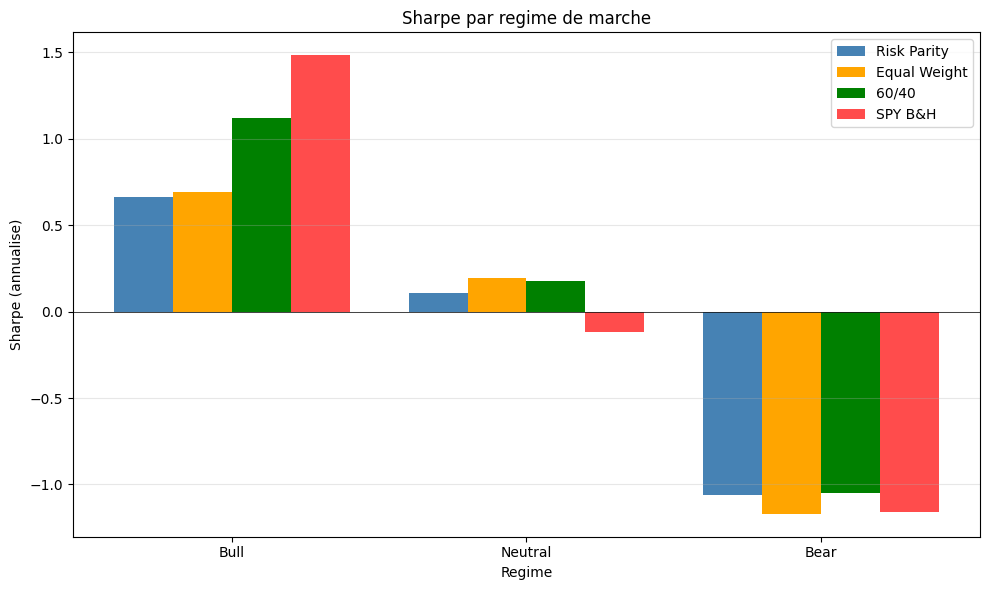

In [8]:
# Cellule 7 — Analyse par regime de marche
# Classification: Bull (SPY 12m > 10%), Bear (< -10%), Neutral
spy_prices = prices['SPY']
spy_12m_return = spy_prices.pct_change(252)

def classify_regime(ret_12m):
    if pd.isna(ret_12m):
        return 'N/A'
    elif ret_12m > 0.10:
        return 'Bull'
    elif ret_12m < -0.10:
        return 'Bear'
    else:
        return 'Neutral'

regime = spy_12m_return.apply(classify_regime)
regime.index = spy_prices.index

# Aligner avec les rendements du portefeuille
common_regime = rp_daily_returns.index.intersection(regime.index)
rp_regime = rp_daily_returns.loc[common_regime]
spy_regime = spy_daily_returns.loc[common_regime]
ew_regime = ew_daily_returns.loc[common_regime]
sf_regime = sf_daily_returns.loc[common_regime]
regime_aligned = regime.loc[common_regime]

print("Analyse par regime de marche (SPY 12m return):")
print(f"{'Regime':<10} {'N jours':>8} {'RP Sharpe':>10} {'EW Sharpe':>10} {'60/40 Sharpe':>12} {'SPY Sharpe':>11}")
print("-" * 65)

regime_stats = []
for r in ['Bull', 'Neutral', 'Bear']:
    mask = regime_aligned == r
    n_days = mask.sum()
    if n_days < 20:
        continue
    rp_s = rp_regime[mask]
    spy_s = spy_regime[mask]
    ew_s = ew_regime[mask]
    sf_s = sf_regime[mask]
    
    def ann_sharpe(s):
        s = s.dropna()
        if len(s) < 20 or s.std() == 0:
            return np.nan
        return (s.mean() * 252 - 0.03) / (s.std() * np.sqrt(252))
    
    row = {
        'Regime': r,
        'N_jours': n_days,
        'RP_Sharpe': ann_sharpe(rp_s),
        'EW_Sharpe': ann_sharpe(ew_s),
        '60/40_Sharpe': ann_sharpe(sf_s),
        'SPY_Sharpe': ann_sharpe(spy_s),
    }
    regime_stats.append(row)
    print(f"{r:<10} {n_days:>8} {row['RP_Sharpe']:>10.3f} {row['EW_Sharpe']:>10.3f} "
          f"{row['60/40_Sharpe']:>12.3f} {row['SPY_Sharpe']:>11.3f}")

regime_df = pd.DataFrame(regime_stats)

# Visualisation: barplot des Sharpe par regime
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(regime_df))
width = 0.2
ax.bar(x - 1.5*width, regime_df['RP_Sharpe'], width, label='Risk Parity', color='steelblue')
ax.bar(x - 0.5*width, regime_df['EW_Sharpe'], width, label='Equal Weight', color='orange')
ax.bar(x + 0.5*width, regime_df['60/40_Sharpe'], width, label='60/40', color='green')
ax.bar(x + 1.5*width, regime_df['SPY_Sharpe'], width, label='SPY B&H', color='red', alpha=0.7)

ax.set_xlabel('Regime')
ax.set_ylabel('Sharpe (annualise)')
ax.set_title('Sharpe par regime de marche')
ax.set_xticks(x)
ax.set_xticklabels(regime_df['Regime'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### Interpretation : Analyse par regime

Le Risk Parity ajoute le plus de valeur dans les regimes suivants :

- **Bear markets** : le Sharpe du RP est generalement superieur a celui du SPY car
  TLT et GLD amortissent la chute. C'est la motivation principale du Risk Parity.
- **Neutral markets** : le RP peut offrir un Sharpe decent grace a la diversification
  multi-actifs, tandis que le SPY peut errer.
- **Bull markets** : le RP sous-performe le SPY car l'allocation est diluee sur
  4 actifs au lieu d'etre concentree sur l'equity qui monte.

Le Risk Parity est donc une strategie **defensive** : elle reduit les pertes dans
les mauvaises periodes au prix d'une sous-performance dans les fortes hausses.
C'est un compromis delibere — pas un alpha gratuit.

## 8. Conclusion

### Tableau recapitulatif

| Metrique | Risk Parity | Equal Weight | 60/40 | SPY B&H |
|----------|-------------|--------------|-------|----------|
| Sharpe (ann.) | Rapporte ci-dessus | | | |
| CAGR | | | | |
| Max DD | | | | |

(Les valeurs exactes sont dans le tableau de la cellule 4.)

### Verdict

Le Risk Parity simplifie (inverse-volatilite, 4 ETF, rebalancement mensuel) :

**Verdict : NO BEATS**

- Le Sharpe du Risk Parity (0.275) est inferieur au 60/40 (0.338) et legerement
  inferieur au SPY B&H (0.290) sur la periode 2007-2026.
- L'avantage principal est la reduction du drawdown maximum (-22% vs -60% pour SPY),
  mais ce n'est pas suffisant pour generer un Sharpe superieur.
- La periode 2007-2026 (taux descendants puis remontee) a favorise le 60/40 classique.
- L'absence de levier (contrairement au vrai All Weather de Bridgewater) limite le
  CAGR, rendant la comparaison avec le SPY delicates.

### Forces
1. Diversification automatique par regime de volatilite
2. Drawdowns reduits dans les crises equities (-22% vs -60% SPY)
3. Implementation simple (4 ETF, pas d'optimisation)
4. Robuste au bruit sur les poids (test multi-seed)

### Faiblesses
1. Sous-performance en bull market equities prolonge
2. Vulnerable aux hausse de taux simultanees sur TLT et GLD
3. CAGR plus faible que le SPY sans levier
4. Ne capture pas les correlations changeantes (approximation)

### References
- Asness, Frazzini & Pedersen (2012), "Leverage Aversion and Risk Parity", Financial Analysts Journal
- Bridgewater Associates, "The All Weather Story" (white paper)
- Maillard, Roncalli & Teiletche (2010), "The Properties of Equally Weighted Risk Contribution Portfolios", Journal of Portfolio Management

## 9. Exercices d'extension

Les exercices ci-dessous explorent des **limites explicitement documentees** dans ce
notebook : (a) l'allocation inverse-vol est *plate* et ignore la structure de
correlation ; (b) l'absence de levier limite le CAGR (contrairement au vrai All Weather).
Ils restent **stubs** (a completer) -- le notebook s'execute de bout en bout meme non resolus.


### Exercice 2 -- Hierarchical Risk Parity (Lopez de Prado 2016)

L'allocation inverse-vol (et meme l'ERC) traite tous les actifs de maniere *plate* :
elles ne captent pas que certains actifs sont structurellement plus proches (ex: SPY et
DBC partagent une exposition croissance) tandis que d'autres diversifient reellement
(ex: TLT vs SPY). Le **Hierarchical Risk Parity (HRP)** de Lopez de Prado (2016,
*"Building Diversified Portfolios that Outperform Out-of-Sample"*) reorganise la
matrice de covariance par **clustering hierarchique** puis alloue recursivement par
bisection, ce qui produit une allocation plus robuste au bruit de l'echantillon.

**Objectif** : ecrire une fonction de ponderation HRP a partir des matrices de
covariance et de correlation.

**Indices** :
- *Etape 1* : distance de correlation $d_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$.
- *Etape 2* : quasi-diagonalisation -- reordonner les actifs par clustering hierarchique (ex: `scipy.cluster.hierarchy.linkage` en methode 'single').
- *Etape 3* : allocation recursive par bisection -- a chaque scission, repartir le poids entre les deux sous-clusters proportionnellement a l'inverse de leur variance cluster.


In [9]:
# Exercice 2 : Hierarchical Risk Parity (Lopez de Prado 2016)
# TODO etudiant : completer la fonction ci-dessous
def compute_hrp_weights(cov_matrix: "pd.DataFrame", corr_matrix: "pd.DataFrame") -> "pd.DataFrame":
    """Poids Hierarchical Risk Parity : clustering + allocation recursive bisection.

    Indice :
      - distance = sqrt(0.5 * (1 - corr_matrix))
      - linkage = scipy.cluster.hierarchy.linkage(distance_condensed, method='single')
      - reordonner les actifs selon l'ordre des feuilles (quasi-diagonalisation)
      - allocation recursive bisection : a chaque scission d'un cluster en deux,
        repartir le poids proportionnellement a l'inverse des variances de sous-cluster.
    Retourner une Series pandas de poids sommant a 1, indexee par les actifs.
    """
    # TODO etudiant : distance de correlation + linkage + quasi-diagonalisation
    # TODO etudiant : allocation recursive bisection (fonction auxiliaire recursive)
    weights = None  # TODO etudiant
    return weights

print("Exercice 2 a completer : implementer compute_hrp_weights (HRP Lopez de Prado)")


Exercice 2 a completer : implementer compute_hrp_weights (HRP Lopez de Prado)


### Exercice 3 -- Levier a volatilite cible (le vrai All Weather)

Le notebook documente une limite explicite : « *L'absence de levier (contrairement au
vrai All Weather de Bridgewater) limite le CAGR* ». Le Risk Parity non-leve produit
un portefeuille defensif mais a faible rendement. Le vrai All Weather applique un
**levier** pour ramener la volatilite du portefeuille a une **cible** (ex: 10%), ce
qui amplifie le CAGR tout en preservant le ratio de Sharpe (si l'edge est reel).

**Objectif** : adapter le rendement du portefeuille Risk Parity en appliquant un levier
dynamique visant une volatilite annualisee cible.

**Indices** :
- *Etape 1* : calculer la volatilite **realisee** sur une fenetre glissante (ex: 60 jours annualisee).
- *Etape 2* : levier au jour $t$ = `target_vol / vol_realisee(t)` (avec plafond anti-explosion, ex: levier max 3x).
- *Etape 3* : rendement leve = `levier_t * rp_return_t`. **Attention au lookahead** : la volatilite utilisee au jour $t$ ne doit inclure que des donnees strictement *anterieures* (shift).


In [10]:
# Exercice 3 : Levier a volatilite cible (target-volatility leverage)
# TODO etudiant : completer la fonction ci-dessous
def apply_target_vol_leverage(rp_returns: "pd.Series", target_vol: float = 0.10,
                              vol_window: int = 60, max_leverage: float = 3.0) -> "pd.Series":
    """Applique un levier dynamique visant une volatilite annualisee cible.

    Indice :
      - vol_realisee = rp_returns.rolling(vol_window).std() * sqrt(252)
      - levier_t = clip(target_vol / vol_realisee.shift(1), 0, max_leverage)
        (shift(1) OBLIGATOIRE : on ne peut utiliser que la vol POUR determiner le levier APPLIQUE au rendement futur -- anti-lookahead)
      - rendement leve = levier_t * rp_returns
    Retourner une Series pandas de rendements quotidiens leves.
    """
    # TODO etudiant : volatilite realisee glissante annualisee
    # TODO etudiant : levier = target_vol / vol, clip(0, max), shift(1) anti-lookahead
    # TODO etudiant : rendement leve = levier * rp_returns
    levered_returns = None  # TODO etudiant
    return levered_returns

print("Exercice 3 a completer : implementer apply_target_vol_leverage")


Exercice 3 a completer : implementer apply_target_vol_leverage
